In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [20]:
img_size = 224
batch_size = 32
dataset_path='Dataset/'
train_dir = os.path.join(dataset_path, 'train_another')
val_dir = os.path.join(dataset_path, 'validation_another')
test_dir = os.path.join(dataset_path, 'test_another')

In [21]:
train_datagen=ImageDataGenerator(rescale=1./255,
                                 rotation_range=30,
                                 horizontal_flip=True,
                                 width_shift_range=0.1,
                                 height_shift_range=0.1,
                                 zoom_range=0.2)
val_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

In [22]:
train_generator=train_datagen.flow_from_directory(train_dir,
                                                  target_size=(img_size,img_size),
                                                  batch_size=batch_size,
                                                  class_mode='binary',
                                                  shuffle=True)
val_generator=val_datagen.flow_from_directory(val_dir,
                                                target_size=(img_size,img_size),
                                                batch_size=batch_size,
                                                class_mode='binary',
                                                shuffle=False)
test_generator=test_datagen.flow_from_directory(test_dir,
                                                  target_size=(img_size,img_size),
                                                  batch_size=batch_size,
                                                  class_mode='binary',
                                                  shuffle=False)


Found 10000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Found 9000 images belonging to 2 classes.


In [23]:
train_generator.class_indices

{'damage': 0, 'no_damage': 1}

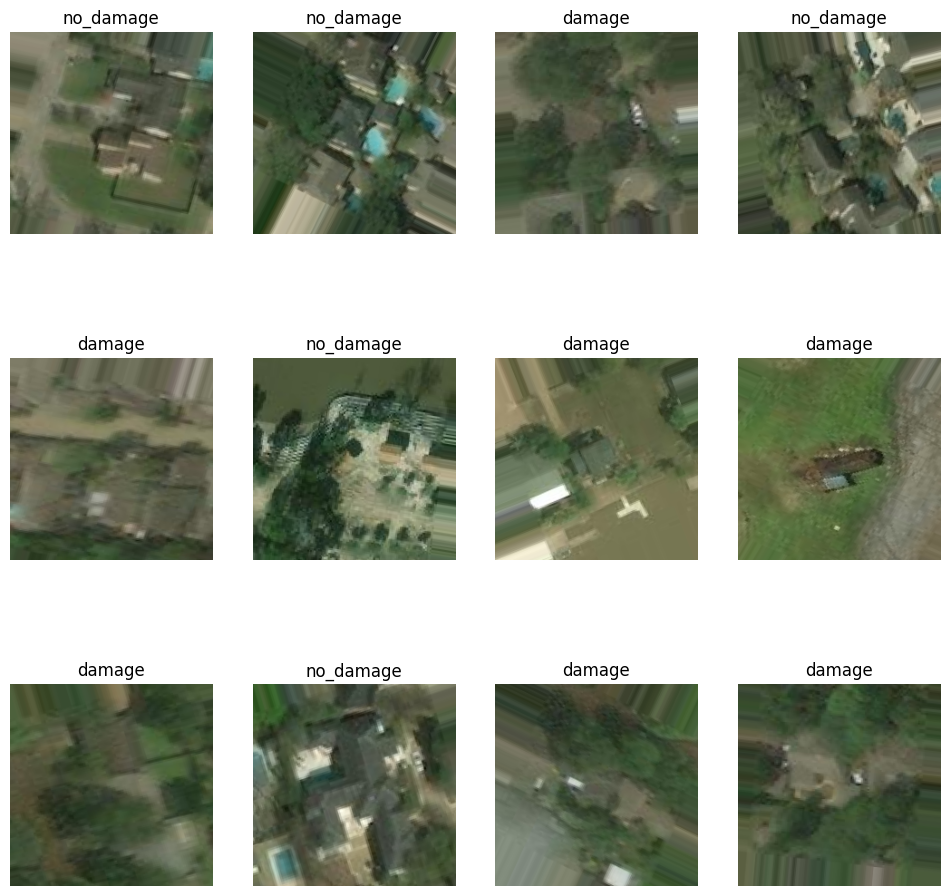

In [24]:
labels=list(train_generator.class_indices.keys())
images,targets=next(train_generator)
plt.figure(figsize=(12,12))
for i in range(12):
    
    plt.subplot(3,4,i+1)
    plt.imshow(images[i])
    
    label = labels[int(targets[i])]
    plt.title(label)
    
    plt.axis("off")

plt.show()

In [25]:
print("Training samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Training samples: 10000
Validation samples: 2000
Test samples: 9000


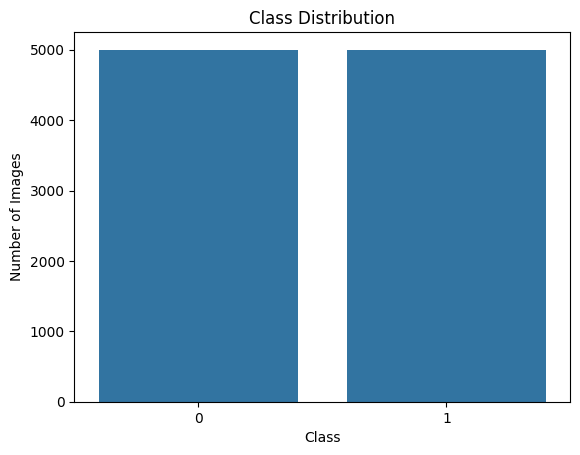

In [26]:
train_classes=train_generator.classes

sns.countplot(x=train_classes)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [27]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [28]:
base_model=Xception(include_top=False,
                    weights='imagenet',
                    input_shape=(img_size,img_size,3))

In [29]:
for layer in base_model.layers:
    layer.trainable = False

In [30]:
model=Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [31]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,552,105 (177.58 MB)

 Trainable params: 25,690,625 (98.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [33]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [34]:
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

C:\Users\Asif\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
 77/313 ━━━━━━━━━━━━━━━━━━━━ 16:07 4s/step - accuracy: 0.7557 - loss: 0.5964

KeyboardInterrupt: 

In [ ]:
model.save("hurricane_damage_model.keras")